# Elasticity Before Electronics
### *Modern Strain Gage Technology* — Companion Notebook

**The strain gage is less than a century old; the physics it reads dates to Robert Hooke in 1678 — this notebook connects that ancient law to the calibration constant of every modern transducer.**

Companion notebook to Chapter 3 — Elasticity Before Electronics.

The strain gage was invented in 1938. The physics it measures is much older. Robert Hooke published his law of elastic deformation in 1678 — *ut tensio, sic vis* (as the extension, so the force) — establishing the proportional relationship between force and deformation that underlies every modern load cell, pressure transducer, and structural health monitoring system. Two hundred and sixty years separate Hooke from the foil gage, but the measurement is fundamentally the same: how much did this thing deform, and what does that tell us about the force acting on it?

The material properties that govern elastic deformation — Young's modulus E, Poisson's ratio ν, shear modulus G — determine the calibration constant of every strain-gage-based transducer. A cantilever beam designed to produce 1000 με at 100 N of applied load relies on the beam geometry and the material modulus. If the modulus is wrong — because the wrong alloy was used, or because the material was not heat-treated correctly — the transducer sensitivity will be off by the same percentage as the modulus error. Understanding elasticity is a prerequisite for understanding why the measurement has the value it does.

Both demonstrations below are bounded by the same constraint, and it is the one beginners most often violate: Hooke's law is a *contract with conditions*. It holds up to the yield point and not past it, and the yield point is a property of the specific alloy and temper — not of "steel" or "aluminum." Every material in this notebook is therefore named by its specification, and every modulus and yield strength carries a source. The second figure plots not only how much each material strains under a common stress, but how much elastic range it has left when it gets there — which turns out to reorder the list.

**This notebook demonstrates:**
1. **Hooke's Law** — force, stress, and strain for an ASTM A36 steel specimen, swept to 80% of yield with the end of the linear contract marked
2. **Material comparison** — elastic strain and remaining elastic headroom across six specified materials at a common applied stress

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures are written here; the book \includegraphics these exact filenames.
OUT_DIR = Path("../src/media/ch03")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Hooke's Law: Force, Stress, and Strain

Robert Hooke's law states that force is proportional to extension in the elastic range — a relationship he encoded in the anagram "ceiiinosssttuv" in 1676 before revealing it as *ut tensio, sic vis* (as the extension, so the force) two years later. In modern form, the material version of this law is σ = Eε: stress equals Young's modulus multiplied by strain. This single equation relates the external force applied to a specimen to the internal deformation it experiences.

The left panel shows force vs. stress for a steel rod — a straight line whose slope is determined only by cross-sectional area, not by material. The right panel shows stress vs. strain — a straight line whose slope is Young's modulus, a material property independent of geometry. The strain gage on the rod measures strain; the material modulus converts that strain to stress; the specimen geometry converts stress to force. Every strain-gage-based transducer is a realization of this chain.

The specimen is ASTM A36 structural steel: E = 200 GPa, minimum specified yield 250 MPa, which puts the end of the elastic range at 1,250 με. The load sweep stops at 200 MPa — 80% of yield, 1,000 με — and the shaded region beyond marks where the straight line stops being true. This matters more than it looks. A plot of Hooke's law drawn past yield is not a conservative approximation; it is a different physical regime rendered as though it were the same one, and the strain gage will happily report numbers from it.

Configurable parameters: change `E_GPA` and `YIELD_MPA` together to simulate a different spring element material — they are a matched pair, and changing one without the other is the modulus error described above. `L_MM` and `A_MM2` set the specimen geometry, and `UTILIZATION` sets how far up the elastic range the sweep runs.

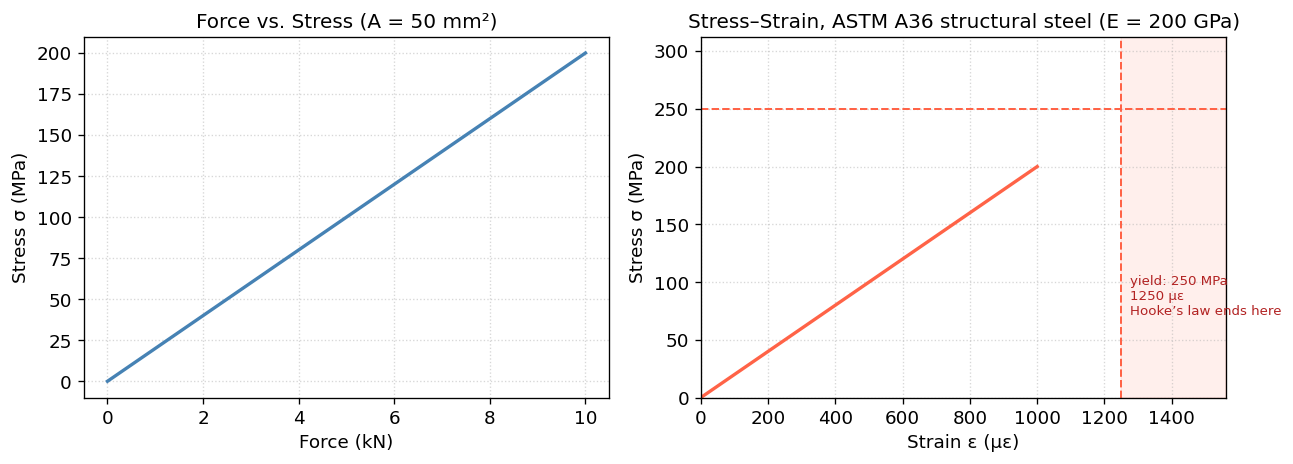

ASTM A36 structural steel: E = 200 GPa, yield 250 MPa (1250 με)
At F = 10.0 kN (80% of yield):  σ = 200.0 MPa,  ε = 1000 με,  δ = 0.1000 mm


In [2]:
# --- USER INPUT: describe the specimen and the load range ---------------------
# Material and yield strength are a matched pair. See the sources cell below.
MATERIAL    = 'ASTM A36 structural steel'
E_GPA       = 200.0    # Young's modulus (GPa)
YIELD_MPA   = 250.0    # minimum specified tensile yield strength (MPa)
L_MM        = 100.0    # specimen gage length (mm)
A_MM2       = 50.0     # cross-sectional area (mm^2)
UTILIZATION = 0.80     # sweep to this fraction of yield stress; must stay < 1
N_POINTS    = 200      # number of samples along the load sweep

MPA_PER_GPA           = 1e3  # 1 GPa = 1000 MPa; with N and mm^2, stress comes out in MPa
STRAIN_TO_MICROSTRAIN = 1e6  # dimensionless strain -> microstrain (με)

assert UTILIZATION < 1.0, "The sweep must stay inside the elastic range."


def axial_response(force_N, area_mm2, length_mm, modulus_GPa):
    """Elastic axial response of a uniform bar in tension (Hooke's Law).

    Applies the material form of Hooke's Law, sigma = E * eps. With force in
    newtons and area in mm^2, stress comes out directly in MPa (1 N/mm^2 = 1 MPa).
    Valid only below the yield stress of the material.

    Returns
    -------
    (stress_MPa, strain, extension_mm)
        Each output matches the shape of ``force_N``.
    """
    modulus_MPa  = modulus_GPa * MPA_PER_GPA
    stress_MPa   = force_N / area_mm2        # sigma = F / A
    strain       = stress_MPa / modulus_MPa  # eps = sigma / E  (dimensionless)
    extension_mm = strain * length_mm        # delta = eps * L
    return stress_MPa, strain, extension_mm


# Size the load sweep from the material, not the other way round.
F_max_N = UTILIZATION * YIELD_MPA * A_MM2
yield_strain_ue = YIELD_MPA / (E_GPA * MPA_PER_GPA) * STRAIN_TO_MICROSTRAIN

F = np.linspace(0, F_max_N, N_POINTS)
sigma, eps, delta = axial_response(F, A_MM2, L_MM, E_GPA)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(F / 1000, sigma, 'steelblue', linewidth=2)
axes[0].set_xlabel('Force (kN)')
axes[0].set_ylabel('Stress σ (MPa)')
axes[0].set_title(f'Force vs. Stress (A = {A_MM2:.0f} mm²)')
axes[0].grid(True, linestyle=':', alpha=0.5)

eps_ue = eps * STRAIN_TO_MICROSTRAIN
strain_limit = yield_strain_ue * 1.25
axes[1].axvspan(yield_strain_ue, strain_limit, color='tomato', alpha=0.10)
axes[1].axvline(yield_strain_ue, color='tomato', linestyle='--', linewidth=1.2)
axes[1].axhline(YIELD_MPA, color='tomato', linestyle='--', linewidth=1.2)
axes[1].plot(eps_ue, sigma, 'tomato', linewidth=2)
axes[1].text(yield_strain_ue * 1.02, YIELD_MPA * 0.35,
             f'yield: {YIELD_MPA:.0f} MPa\n{yield_strain_ue:.0f} με\n'
             'Hooke\u2019s law ends here',
             fontsize=8, color='firebrick', va='center')
axes[1].set_xlabel('Strain ε (με)')
axes[1].set_ylabel('Stress σ (MPa)')
axes[1].set_title(f'Stress–Strain, {MATERIAL} (E = {E_GPA:.0f} GPa)')
axes[1].set_xlim(0, strain_limit)
axes[1].set_ylim(0, YIELD_MPA * 1.25)
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig03_nb1_hookes_law_force_stress.png', bbox_inches='tight', dpi=150)
plt.show()

sigma_max, eps_max, delta_max = axial_response(F_max_N, A_MM2, L_MM, E_GPA)
print(f"{MATERIAL}: E = {E_GPA:.0f} GPa, yield {YIELD_MPA:.0f} MPa "
      f"({yield_strain_ue:.0f} με)")
print(f"At F = {F_max_N/1000:.1f} kN ({UTILIZATION:.0%} of yield):  "
      f"σ = {sigma_max:.1f} MPa,  "
      f"ε = {eps_max * STRAIN_TO_MICROSTRAIN:.0f} με,  "
      f"δ = {delta_max:.4f} mm")

---
## 2 — Material Comparison: Strain, and How Much Range Is Left

At the same applied stress, different materials deform by very different amounts. Aluminum 6061-T6, with E = 68.9 GPa, deforms about three times more than A36 steel at 200 GPa. Human cortical bone, at E ≈ 17 GPa, deforms roughly twelve times more than steel under the same stress. This diversity is what makes spring element material selection a genuine engineering decision: a stiffer element produces less strain per unit load, requiring a more sensitive measurement system; a more compliant element produces more strain but may introduce unacceptable structural compliance in the application.

But strain at a given stress is only half the picture, and reading the chart by bar length alone is misleading. What a designer needs to know is how much of the material's elastic range that strain consumes — and the ranking by *utilization* is not the ranking by strain. At the common 50 MPa used here, annealed C11000 copper strains only 417 με, less than a sixth of what bone does, yet it sits at **72% of its yield strength** because annealed copper yields at just 69 MPa. Cortical bone strains seven times harder and is only a third of the way to yield. Titanium, the stiffest thing on the list after steel, is at 6%.

So the figure below plots both: the bar is strain at the common stress, and the caret marks where that material stops obeying Hooke's law. A short bar close to its caret is a material with nothing left to give.

For transducer design, the most common spring element materials are aluminum 6061-T6 (E ≈ 69 GPa, good machinability) and 17-4PH stainless steel (E ≈ 197 GPa, excellent corrosion resistance). Titanium (E ≈ 114 GPa) is used where corrosion resistance and biocompatibility are required. The choice balances target full-scale strain (typically 1000–3000 με), operating environment, and required fatigue life — and, as the chart shows, the headroom left over when full scale is reached.

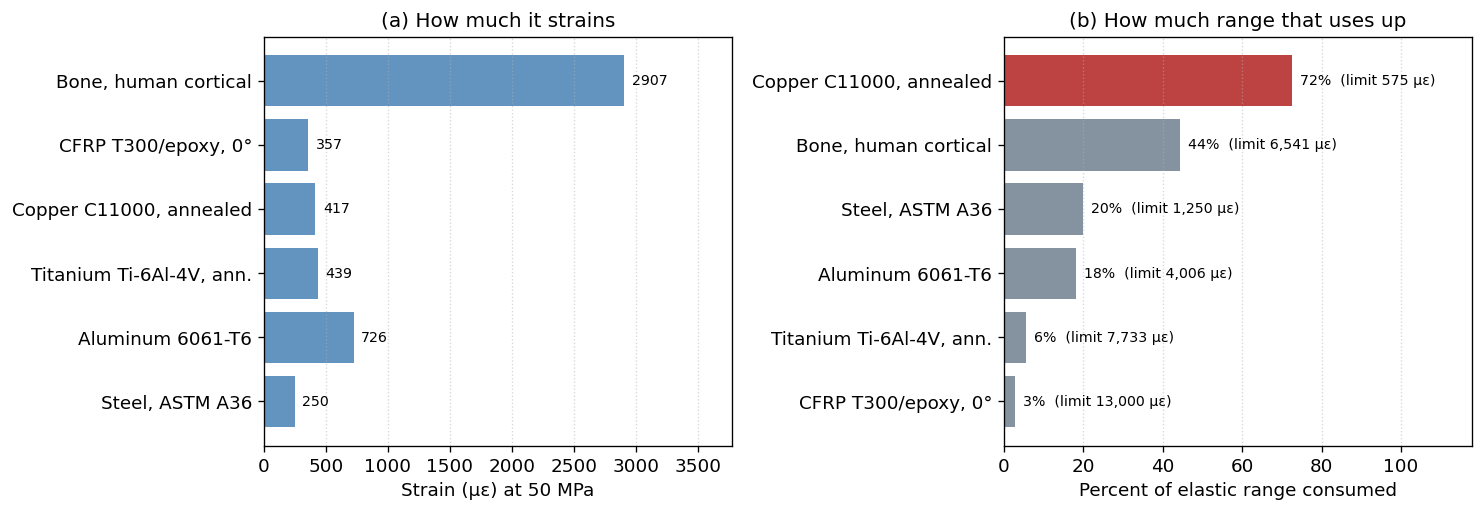

At a common applied stress of 50 MPa:

Material                    E (GPa)    strain     limit    used
Steel, ASTM A36               200.0     250 με    1250 με    20%
Aluminum 6061-T6               68.9     726 με    4006 με    18%
Titanium Ti-6Al-4V, ann.      113.8     439 με    7733 με     6%
Copper C11000, annealed       120.0     417 με     575 με    72%
CFRP T300/epoxy, 0°           140.0     357 με   13000 με     3%
Bone, human cortical           17.2    2907 με    6541 με    44%


In [3]:
# Six materials, each named by specification because E and yield strength are
# properties of an alloy and temper, not of a metal. Sources in the cell below.
#
#  name: (E in GPa, limit stress in MPa, limit label)
# The limit is the tensile yield strength, except for CFRP, which is brittle and
# has no yield point -- its limit is the ultimate tensile strength.
MATERIALS = {
    'Steel, ASTM A36':          (200.0,  250.0, 'yield'),
    'Aluminum 6061-T6':         ( 68.9,  276.0, 'yield'),
    'Titanium Ti-6Al-4V, ann.': (113.8,  880.0, 'yield'),
    'Copper C11000, annealed':  (120.0,   69.0, 'yield'),
    'CFRP T300/epoxy, 0°':      (140.0, 1820.0, 'ultimate'),
    'Bone, human cortical':     ( 17.2,  112.5, 'yield'),
}
COMMON_STRESS_MPA = 50.0  # applied to every material; elastic for all six
LABEL_OFFSET_UE   = 60.0  # horizontal nudge (με) so value labels clear the bar ends


def elastic_strain_ue(stress_MPa, modulus_GPa):
    """Axial elastic strain from Hooke's Law (eps = sigma / E), in microstrain.

    Stress in MPa and modulus in GPa differ by a factor of 1e3, so MPa/GPa is
    millistrain; multiplying by 1e3 converts to microstrain (με).
    """
    return stress_MPa / modulus_GPa * 1e3


names = list(MATERIALS)
strains_ue = [elastic_strain_ue(COMMON_STRESS_MPA, E) for E, _, _ in MATERIALS.values()]
limits_ue = [elastic_strain_ue(limit, E) for E, limit, _ in MATERIALS.values()]
utilisation = [s / l for s, l in zip(strains_ue, limits_ue)]

order = np.argsort(utilisation)          # ascending, so the worst case is on top

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))

# --- (a) strain at a common stress: linear axis, bar length means something ---
ax1.barh(names, strains_ue, color='steelblue', alpha=0.85)
for i, strain in enumerate(strains_ue):
    ax1.text(strain + LABEL_OFFSET_UE, i, f'{strain:.0f}', va='center', fontsize=8.5)
ax1.set_xlabel(f'Strain (\u03bc\u03b5) at {COMMON_STRESS_MPA:.0f} MPa')
ax1.set_xlim(0, max(strains_ue) * 1.30)
ax1.set_title('(a) How much it strains')
ax1.grid(True, axis='x', linestyle=':', alpha=0.5)

# --- (b) the same six, reordered by how much elastic range that consumes -----
ordered_names = [names[i] for i in order]
ordered_util = [utilisation[i] * 100 for i in order]
ordered_limit = [limits_ue[i] for i in order]
colors = ['firebrick' if u > 50 else 'slategray' for u in ordered_util]

ax2.barh(ordered_names, ordered_util, color=colors, alpha=0.85)
for i, (u, lim) in enumerate(zip(ordered_util, ordered_limit)):
    ax2.text(u + 2, i, f'{u:.0f}%  (limit {lim:,.0f} \u03bc\u03b5)',
             va='center', fontsize=8.5)
ax2.set_xlabel('Percent of elastic range consumed')
ax2.set_xlim(0, 118)
ax2.set_title('(b) How much range that uses up')
ax2.grid(True, axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig03_nb2_material_elastic_strain.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"At a common applied stress of {COMMON_STRESS_MPA:.0f} MPa:\n")
print(f"{'Material':<26}{'E (GPa)':>9}{'strain':>10}{'limit':>10}{'used':>8}")
for name, (E, limit, kind), st, lim, u in zip(
        names, MATERIALS.values(), strains_ue, limits_ue, utilisation):
    print(f"{name:<26}{E:>9.1f}{st:>8.0f} \u03bc\u03b5{lim:>8.0f} \u03bc\u03b5{u:>7.0%}")

### Figures 3.2 and 3.3 — material data and sources

Every modulus and limit stress below is a published value for a named specification. Where a range is published, the median or the commonly cited design value is used.

| Material | E (GPa) | Limit stress (MPa) | Source |
|---|---|---|---|
| Steel, ASTM A36 | 200 | 250, minimum specified yield | ASTM A36/A36M, *Standard Specification for Carbon Structural Steel* (minimum yield 36 ksi). |
| Aluminum 6061-T6 | 68.9 | 276, yield | ASM Handbook Vol. 2, *Properties and Selection: Nonferrous Alloys*; design allowables in MIL-HDBK-5J / MMPDS. |
| Titanium Ti-6Al-4V, annealed | 113.8 | 880, yield | ASM Handbook Vol. 2. Published ranges: E 104–113 GPa, yield 880–920 MPa. |
| Copper C11000, annealed (OS050) | 120 | 69, yield | Copper Development Association / ASM data for ETP copper, OS050 temper (UTS 220 MPa, elongation 50%). |
| CFRP, T300/epoxy unidirectional, 0°, Vᶠ ≈ 60% | 140 | 1,820, **ultimate** — no yield point | Toray Composite Materials America, *TORAYCA T300 Standard Modulus Carbon Fiber Data Sheet* (composite tensile modulus 140 GPa, tensile strength 1,820 MPa, tensile strain 1.26%). |
| Bone, human cortical, femoral diaphysis, longitudinal | 17.2 (median) | 112.5, yield (median) | Baleani, M., Erani, P., Acciaioli, A., and Schileo, E. (2024). "Tensile Yield Strain of Human Cortical Bone from the Femoral Diaphysis Is Constant among Healthy Adults and across the Anatomical Quadrants." *Bioengineering* 11(4), 395. 80 specimens, 5 donors; median yield strain 0.83% (range 0.77–0.87%), E 12.2–20.5 GPa, yield stress 75.9–136.6 MPa. |

**Notes and caveats.**

1. **A metal's name is not a specification.** "Steel" spans a yield strain from about 1,250 με (A36) to nearly 6,400 με (17-4PH in the H900 condition, yield 1,260 MPa at E ≈ 197 GPa) — a factor of five, at essentially the same modulus. "Aluminum" spans 6061-T6 at roughly 4,000 με to 7075-T6 at over 7,000. Any statement of the form "steel yields at X microstrain" is incomplete without the alloy and temper.
2. **CFRP does not yield.** It is brittle in the fiber direction and fails without a plastic region, so its bar is marked against ultimate tensile strength, not a yield point. Treating a composite's strength as a "yield" invites a design margin that does not exist — there is no plastic reserve behind it.
3. **Bone is a range, not a number.** The 17.2 GPa and 112.5 MPa used here are medians from a single well-controlled study of middle-aged male donors. Modulus varies with donor age, anatomical site, orientation, and loading rate; bovine cortical bone tests substantially stiffer and stronger than human. The value is representative, not universal. There is also a subtlety worth naming: composing the median modulus with the median yield stress gives a yield strain of 6,541 με, whereas the study's *directly measured* median yield strain is 0.83% — about 8,300 με. Medians do not compose. The chart uses the composed figure so that all six materials are computed the same way, but the directly measured strain is the better number, and the 20% gap between them is a fair estimate of how much precision this row really carries.
4. **50 MPa is elastic for all six, but not comfortably so for one.** Annealed C11000 copper yields at 69 MPa, so the common stress puts it at 72% of yield while A36 steel sits at 20% and Ti-6Al-4V at under 6%. That is the point of the caret markers: equal stress is not equal severity.

---
## Where to take this next

Hooke's Law is the starting point, not the destination. Three concrete extensions build directly on the code above:

- **Sweep the alloy, not just the load.** The yield markers in Figure 3.3 show that "steel" and "aluminum" each span a factor of several in elastic range. Add 17-4PH H900, 7075-T6, and annealed vs. half-hard copper to `MATERIALS` and re-plot; the chart becomes a spring-element shortlist rather than a physics illustration.
- **Size a transducer, don't just plot it.** Wrap `axial_response` in a loop over candidate cross-sections and moduli and solve for the geometry that hits a target full-scale strain — say 1500 με at rated load — subject to a maximum utilization of yield. That inversion, from stress and strain back to geometry with a margin constraint, is exactly the spring-element sizing done for real load cells in Part 7.
- **Bring in Poisson's ratio.** Extend the model with the transverse strain εₜ = −ν·εₐₓᵢₐₗ so the notebook predicts what a *transverse* gage would read alongside the axial one. That two-directional strain state is the groundwork for the biaxial stress analysis developed in Chapters 17–18.